=== Linear SVM ===
Accuracy: 0.95
[[26  3]
 [ 0 31]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        29
           1       0.91      1.00      0.95        31

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60


=== RBF SVM ===
Accuracy: 0.9666666666666667
[[28  1]
 [ 1 30]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.97      0.97      0.97        31

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60


Cross Validation Accuracy (RBF): 0.9400000000000001

Best Parameters from GridSearch: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.975


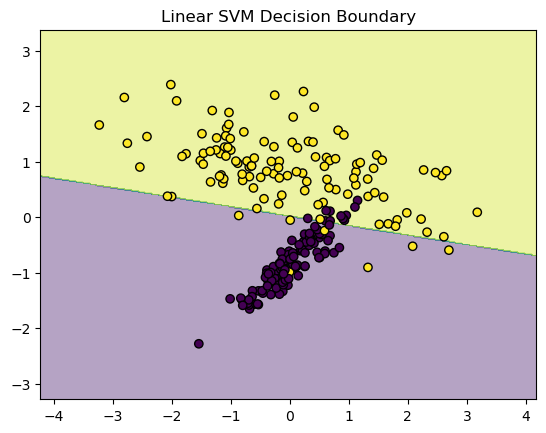

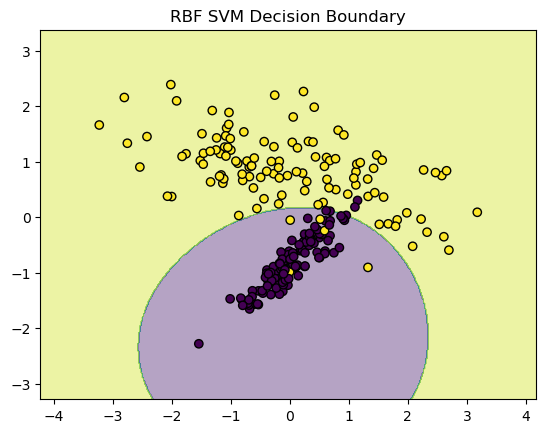

In [1]:
# Task 7: Support Vector Machines (SVM)
# =====================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Binary Classification Dataset (2D for Visualization)
X, y = datasets.make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Train Linear SVM
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train, y_train)

# 5. Train RBF SVM
rbf_svm = SVC(kernel='rbf', C=1, gamma=0.1)
rbf_svm.fit(X_train, y_train)

# 6. Evaluate Models
print("=== Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, linear_svm.predict(X_test)))
print(confusion_matrix(y_test, linear_svm.predict(X_test)))
print(classification_report(y_test, linear_svm.predict(X_test)))

print("\n=== RBF SVM ===")
print("Accuracy:", accuracy_score(y_test, rbf_svm.predict(X_test)))
print(confusion_matrix(y_test, rbf_svm.predict(X_test)))
print(classification_report(y_test, rbf_svm.predict(X_test)))

# 7. Cross Validation
cv_scores = cross_val_score(rbf_svm, X, y, cv=5)
print("\nCross Validation Accuracy (RBF):", np.mean(cv_scores))

# 8. Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\nBest Parameters from GridSearch:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

# 9. Decision Boundary Visualization
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

# Plot for Linear SVM
plot_decision_boundary(linear_svm, X_train, y_train, "Linear SVM Decision Boundary")

# Plot for RBF SVM
plot_decision_boundary(rbf_svm, X_train, y_train, "RBF SVM Decision Boundary")